In [150]:
using Pkg
using CSV
using DataFrames
using Polynomials
using CairoMakie
using Statistics


using SymPy
using LinearAlgebra
using SparseArrays
using Statistics
using Optim

using Serialization


## Functions

In [151]:
#### Log
    ## 
###############################

function simulate_stress(ParyModel,ϵ,dϵdt)

    ## Maxwell
    #k1,k2,n=[ParyModel[1],ParyModel[2],ParyModel[3]]
    #σ=dϵdt*n*(1 .- exp.(-k2.*ϵ./(n*dϵdt))) .+k1 .* ϵ 

    ## Prony
    E_inf=ParyModel[1]
    E1=ParyModel[2]
    E2=ParyModel[3]
    E3=ParyModel[4]
    τ1=ParyModel[5]
    τ2=ParyModel[6]
    τ3=ParyModel[7]
    t= ϵ./dϵdt
    E=E_inf.+E1.*exp.(−t/τ1) .+E2.*exp.(−t/τ2) .+E3.*exp.(−t/τ3) 
    
    σ=E.*ϵ
    return σ
end

function simulate_stress2(ParyModel,ϵ,dϵdt)

    ## Maxwell
    #k1,k2,n=[ParyModel[1],ParyModel[2],ParyModel[3]]
    #σ=dϵdt*n*(1 .- exp.(-k2.*ϵ./(n*dϵdt))) .+k1 .* ϵ 

    ## Prony
    E_inf=ParyModel[1]
    E1=ParyModel[2]
    E2=ParyModel[3]
    τ1=ParyModel[4]
    τ2=ParyModel[5]

    t= ϵ./dϵdt
    E=E_inf.+E1.*exp.(−t/τ1) .+E2.*exp.(−t/τ2) 
    
    σ=E.*ϵ
    return σ
end



# Objective function to be minimized (difference between model and experimental data)
function objective_function(ParyModel,σ_exp,ϵ_exp,dϵdt)
    total_error=0
        for i in 1:length(σ_exp)
            σ_sim    = simulate_stress(ParyModel, ϵ_exp[i],dϵdt[i])
            
            # Calculate sum of squared errors
            error = sum((σ_sim .- σ_exp[i]).^2)
            total_error = total_error+error
        end

    return total_error
end

function objective_function2(ParyModel,σ_exp,ϵ_exp,dϵdt)
    total_error=0
        for i in 1:length(σ_exp)
            σ_sim    = simulate_stress2(ParyModel, ϵ_exp[i],dϵdt[i])
            
            # Calculate sum of squared errors
            error = sum((σ_sim .- σ_exp[i]).^2)
            total_error = total_error+error
        end

    return total_error
end




# Main optimization function

function optimize_Pary(ParyModel0,σ_exp,ϵ_exp,dϵdt)
    
    max_iterations=500

    ##Maxwell
    #initial_params = [ParyModel0[1],ParyModel0[2],ParyModel0[3]]

    #lower_bounds = [1e6, 1e9,1e9]
    #upper_bounds = [ 1e15, 1e15, 1e15]

    ## Prony

    #σ=E_inf+E1*exp(−t/τ1) +E2*exp(−t/τ2) 
    lower_bounds = [1e6, 1e6,1e6,1e6,0.00001,0.00001,0.00001]
    upper_bounds = [ 1e15, 1e15, 1e15, 1e15,1e2, 1e2, 1e2]
    initial_params = [ParyModel0[1],ParyModel0[2],ParyModel0[3],ParyModel0[4],ParyModel0[5],ParyModel0[6],ParyModel0[7]]

    # Define the objective function with fixed experimental data
    obj(ParyModel_fit) = objective_function(ParyModel_fit,σ_exp,ϵ_exp,dϵdt)
    
    # Perform optimization using L-BFGS 
    result = optimize(obj, 
                     lower_bounds, 
                     upper_bounds, 
                     initial_params, 
                     Fminbox(LBFGS()),
                     Optim.Options(iterations=max_iterations, show_trace=true))
    
    # Extract optimized parameters
    optimized_params = Optim.minimizer(result)
    minimum_error = Optim.minimum(result)
    
    return optimized_params, minimum_error
end

function optimize_Pary2(ParyModel0,σ_exp,ϵ_exp,dϵdt)
    
    max_iterations=500

    ##Maxwell
    #initial_params = [ParyModel0[1],ParyModel0[2],ParyModel0[3]]

    #lower_bounds = [1e6, 1e9,1e9]
    #upper_bounds = [ 1e15, 1e15, 1e15]

    ## Prony

    #σ=E_inf+E1*exp(−t/τ1) +E2*exp(−t/τ2) 
    lower_bounds = [1e6, 1e6,1e6,0.00001,0.00001]
    upper_bounds = [ 1e15, 1e15, 1e15,1e2, 1e2]
    initial_params = [ParyModel0[1],ParyModel0[2],ParyModel0[3],ParyModel0[4],ParyModel0[5]]

    # Define the objective function with fixed experimental data
    obj(ParyModel_fit) = objective_function2(ParyModel_fit,σ_exp,ϵ_exp,dϵdt)
    
    # Perform optimization using L-BFGS 
    result = optimize(obj, 
                     lower_bounds, 
                     upper_bounds, 
                     initial_params, 
                     Fminbox(LBFGS()),
                     Optim.Options(iterations=max_iterations, show_trace=true))
    
    # Extract optimized parameters
    optimized_params = Optim.minimizer(result)
    minimum_error = Optim.minimum(result)
    
    return optimized_params, minimum_error
end



########### Optimization algorithm ###############

function main(ParyModel0,σ_exp,ϵ_exp,dϵdt)
    
    # Run optimization
    optimized_params, error = optimize_Pary(ParyModel0,σ_exp,ϵ_exp,dϵdt)

    
    return optimized_params,error
end

function main2(ParyModel0,σ_exp,ϵ_exp,dϵdt)
    
    # Run optimization
    optimized_params, error = optimize_Pary2(ParyModel0,σ_exp,ϵ_exp,dϵdt)

    
    return optimized_params,error
end


function import_TIRA(file_path)
    
    df=CSV.read(file_path,DataFrame) 
    df.Zeit = parse.(Float64, replace.(df.Zeit, "," => "."))
    df.Länge = parse.(Float64, replace.(df.Länge, "," => "."))
    df.Weg = parse.(Float64, replace.(df.Weg, "," => "."))
    #df.Dehnung = parse.(Float64, replace.(df.Dehnung, "," => "."))
    df.Kraft = parse.(Float64, replace.(df.Kraft, "," => "."))
    df.dL_ORG = parse.(Float64, replace.(df.dL_ORG, "," => "."))

    return df

end

function filter_range(df::DataFrame, column::String, low, high)
    return filter(row -> low ≤ row[column] ≤ high, df)
end



filter_range (generic function with 1 method)

## Data

In [152]:
path_properties="D:/Scripts/Rini/development/04 zugversuch/Results/parylene-properties.jls"
df_properties= deserialize(path_properties)

path_curves="D:/Scripts/Rini/development/04 zugversuch/Results/parylene-curves.jls"
df_curves= deserialize(path_curves)



17-element Vector{Any}:
 4628×9 DataFrame
  Row │ Zeit     Weg      Kraft    Länge    dL_ORG   Name      Stress      Str ⋯
      │ Float64  Float64  Float64  Float64  Float64  String    Float64     Flo ⋯
──────┼─────────────────────────────────────────────────────────────────────────
    1 │    7.46  0.14979    0.0     0.0524   0.0     251006-1   0.0         0. ⋯
    2 │    7.48  0.1501     0.003   0.0524   0.0     251006-1   0.02        0.
    3 │    7.5   0.15042    0.006   0.0543   0.0019  251006-1   0.04        0.
    4 │    7.52  0.15073    0.01    0.0543   0.0019  251006-1   0.0666667   0.
    5 │    7.54  0.15104    0.01    0.0556   0.0032  251006-1   0.0666667   0. ⋯
    6 │    7.56  0.15141    0.014   0.0568   0.0044  251006-1   0.0933333   0.
    7 │    7.58  0.15177    0.016   0.0568   0.0044  251006-1   0.106667    0.
    8 │    7.6   0.15219    0.02    0.0575   0.0051  251006-1   0.133333    0.
  ⋮   │    ⋮        ⋮        ⋮        ⋮        ⋮        ⋮          ⋮           

In [153]:
df_properties

Row,e_max[%],δ_F/δ_B,u_E[GPa],Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,3.41337,39.15,0.00199216,251006-1,2.0424,"[0.2002, 0.7996]",0.0663931,22,3.00055,42.9133,24.5133,1.39721
2,Inf,34.0426,0.00468977,251006-6,2.35,"[0.0, 0.8]",0.135621,22,3.458,55.8,28.1333,4.36887
3,9.81791,32.1285,0.010661,260126-1,2.49,"[0.2, 0.8]",0.291614,22,3.65584,58.3871,27.9355,10.4506
4,5.70716,34.188,0.0165611,251103-1,2.34,"[0.2, 0.8]",0.439246,22,3.77035,63.5333,30.9333,26.9292
5,8.6038,37.2093,0.00261786,260126-3,2.15,"[0.2, 0.8]",0.106963,40,2.44744,31.6129,19.8065,1.13168
6,4.67754,44.1989,0.00893897,260126-5,1.81,"[0.21, 0.8]",0.300484,40,2.97486,41.5484,25.1613,10.942
7,5.34934,34.4828,0.00192924,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,26.9032,17.0323,1.07343
8,12.4127,24.2915,0.00189942,260126-8,2.47,"[0.1, 0.6]",0.0953995,50,1.99102,26.9032,12.9677,1.00339
9,54.867,40.0,0.0222299,251103-5,2.0,"[0.11, 0.8]",1.06232,50,2.09258,27.6,16.7333,9.86833


In [154]:
df_curves[1]

Row,Zeit,Weg,Kraft,Länge,dL_ORG,Name,Stress,Strain,Temperature
,Float64,Float64,Float64,Float64,Float64,String,Float64,Float64,Int64
1,7.46,0.14979,0.0,0.0524,0.0,251006-1,0.0,0.0,22
2,7.48,0.1501,0.003,0.0524,0.0,251006-1,0.02,0.0,22
3,7.5,0.15042,0.006,0.0543,0.0019,251006-1,0.04,0.0019,22
4,7.52,0.15073,0.01,0.0543,0.0019,251006-1,0.0666667,0.0019,22
5,7.54,0.15104,0.01,0.0556,0.0032,251006-1,0.0666667,0.0032,22
6,7.56,0.15141,0.014,0.0568,0.0044,251006-1,0.0933333,0.0044,22
7,7.58,0.15177,0.016,0.0568,0.0044,251006-1,0.106667,0.0044,22
8,7.6,0.15219,0.02,0.0575,0.0051,251006-1,0.133333,0.0051,22
9,7.62,0.1525,0.02,0.0575,0.0051,251006-1,0.133333,0.0051,22


In [155]:
    function filter_range(df::DataFrame, column::String, low, high)
        return filter(row -> low ≤ row[column] ≤ high, df)
    end

filter_range (generic function with 1 method)

## Strain rate dependence

In [209]:
σ_exp=[]
ϵ_exp=[]
dϵdt=[]

n=1
range=[0 1]
for i in [1 2 4]

    df_curve=filter_range(df_curves[i], "Strain",range[1],range[2])

    push!(σ_exp,df_curve[!,:Stress]*1e6)
    push!(ϵ_exp,df_curve[!,:Strain]*1e-2)
    push!(dϵdt,df_properties[i," Strain Rate[%/min]"]*1e-2/60)

end


ParyModel0=[1e9, 1e9,1e9,0.1,0.1] # Prony
ParyModel_fit,error=main2(ParyModel0,σ_exp,ϵ_exp,dϵdt) # Find the better adjusment for the CZM parameter


([2.8725158425950956e9, 1.0853869386455162e9, 1.0101235815465161e9, 19.092742497123332, 0.5754546246299056], 2.140965341365247e14)

In [210]:
σ_exp=[]
ϵ_exp=[]
dϵdt=[]

n=1
range=[0 1.5]
for i in [1 2 3 4]

    df_curve=filter_range(df_curves[i], "Strain",range[1],range[2])

    push!(σ_exp,df_curve[!,:Stress]*1e6)
    push!(ϵ_exp,df_curve[!,:Strain]*1e-2)
    push!(dϵdt,df_properties[i," Strain Rate[%/min]"]*1e-2/60)

end


σ_sim=[]
for i in [1 2 3 4]
    σ_cum=[]
    for ii in ϵ_exp[i]
        push!(σ_cum,simulate_stress2(ParyModel_fit,ii,dϵdt[i]))
    end 
    push!(σ_sim,σ_cum)
end

σ_sim

4-element Vector{Any}:
 Any[0.0, 0.0, 91767.4789200077, 91767.4789200077, 151861.35758747454, 205683.2486912521, 205683.2486912521, 236431.24495964454, 236431.24495964454, 279614.9985611009  …  4.353974623904287e7, 4.357593670349626e7, 4.357593670349626e7, 4.35870726223396e7, 4.35870726223396e7, 4.361212911268312e7, 4.362048148312421e7, 4.362048148312421e7, 4.363718653438285e7, 4.363718653438285e7]
 Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  4.8337925532400504e7, 4.8337925532400504e7, 4.8337925532400504e7, 4.8337925532400504e7, 4.862238656694545e7, 4.862238656694545e7, 4.862238656694545e7, 4.862238656694545e7, 4.862238656694545e7, 4.862238656694545e7]
 Any[0.0, 0.0, 0.0, 486885.2283151692, 486885.2283151692, 955759.1016401177, 955759.1016401177, 955759.1016401177, 1.4090973642122939e6, 1.4090973642122939e6  …  5.248081329348165e7, 5.248081329348165e7, 5.2806825150291525e7, 5.2806825150291525e7, 5.2806825150291525e7, 5.313251184662446e7, 5.313251184662446e7, 5.345787498157

In [211]:

set_theme!(
    fonts = (
        regular = "Times New Roman",
        bold = "Times New Roman",
        italic = "Times New Roman"
    )
)

In [212]:

# Plot the first curve with lines and markers
fig1 = Figure(resolution = (1500, 600));

font=24
ax1_1 = Axis(fig1[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax1_2 = Axis(fig1[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax1_3 = Axis(fig1[1,3],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax1_4 = Axis(fig1[1,4],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



## Fig1

##########
    Makie.scatter!(ax1_1,ϵ_exp[1]*100,σ_exp[1]/1e6;
     label = " Exp $(round(dϵdt[1]*60*100, digits=3)) [%/min]",
     marker = :utriangle,
      markersize = 14,
      color = :orange)

    Makie.lines!(ax1_1,ϵ_exp[1]*100,σ_sim[1]/1e6;
     linewidth = 4, 
     label = "Model $(round(dϵdt[1]*60*100, digits=3)) [%/min]",
     color = :black)
     axislegend(ax1_1, labelsize=font-10, framevisible=false,position = :rb)
##########
    Makie.scatter!(ax1_2,ϵ_exp[2]*100,σ_exp[2]/1e6; 
    markersize=14, 
    label = " Exp $(round(dϵdt[2]*60*100, digits=3)) [%/min]",
      marker = :rect,
      color = :red)

    Makie.lines!(ax1_2,ϵ_exp[2]*100,σ_sim[2]/1e6;
      label = "Model $(round(dϵdt[2]*60*100, digits=3)) [%/min]",
      linewidth = 4, 
      color = :black,
      linestyle = :dash)
    axislegend(ax1_2, labelsize=font-10, framevisible=false,position = :rb)

##########
    Makie.scatter!(ax1_3,ϵ_exp[3]*100,σ_exp[3]/1e6; 
    markersize=14, 
    label = " Exp $(round(dϵdt[3]*60*100, digits=3)) [%/min]",
      marker = :rect,
      color = :blue)
    Makie.lines!(ax1_3,ϵ_exp[3]*100,σ_sim[3]/1e6;
      label = "Model $(round(dϵdt[3]*60*100, digits=3)) [%/min]",
      linewidth = 4, 
      color = :black,
      linestyle = :dash)
    axislegend(ax1_3, labelsize=font-10, framevisible=false,position = :rb)


##########
    Makie.scatter!(ax1_4,ϵ_exp[4]*100,σ_exp[4]/1e6; 
    markersize=14, 
    label = " Exp $(round(dϵdt[4]*60*100, digits=3)) [%/min]",
      marker = :rect,
      color = :yellow)
    Makie.lines!(ax1_4,ϵ_exp[4]*100,σ_sim[4]/1e6;
      label = "Model $(round(dϵdt[4]*60*100, digits=3)) [%/min]",
      linewidth = 4, 
      color = :black,
      linestyle = :dash)
    axislegend(ax1_4, labelsize=font-10, framevisible=false,position = :rb)




Legend()

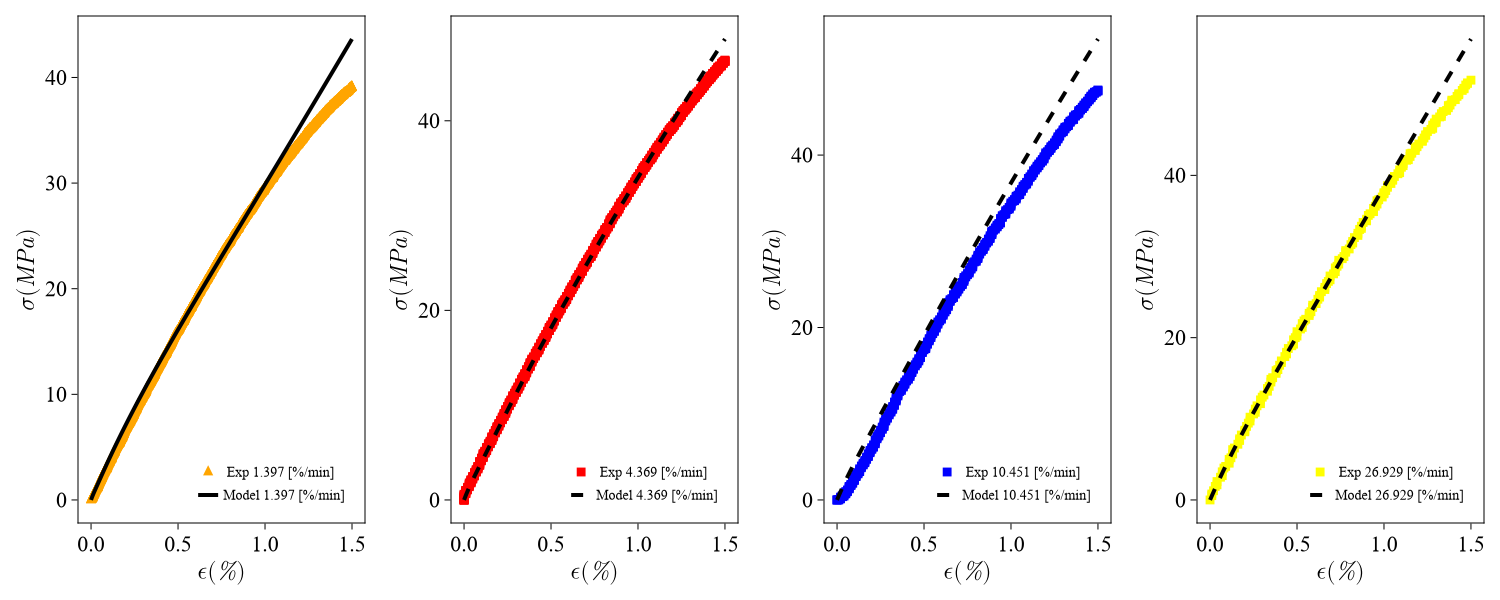

In [213]:
fig1

In [214]:

    ## Prony
    #E_inf=ParyModel[1]
    #E1=ParyModel[2]
    #E2=ParyModel[3]
    #E3=ParyModel[4]
    #τ1=ParyModel[5]
    #τ2=ParyModel[6]
    #τ3=ParyModel[7]
    #t= ϵ./dϵdt
    #E=E_inf.+E1.*exp.(−t/τ1) .+E2.*exp.(−t/τ2) .+E3.*exp.(−t/τ3) 
    


ParyModel_fit

5-element Vector{Float64}:
  2.8725158425950956e9
  1.0853869386455162e9
  1.0101235815465161e9
 19.092742497123332
  0.5754546246299056

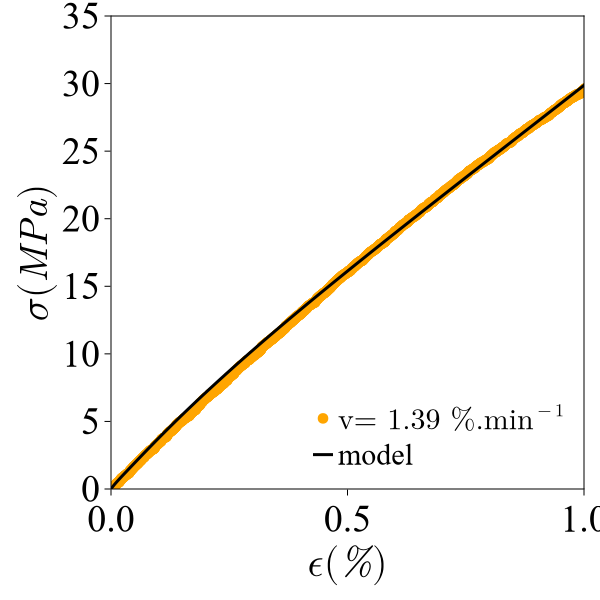

In [243]:
fig = Figure(resolution = (600, 600));

font=40
ax = Axis(fig[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (0,1,0,35)
    )

    Makie.scatter!(ax,ϵ_exp[1]*100,σ_exp[1]/1e6;
     label = L"v= 1.39 %.$\mathrm{min^{-1}}$",
     markersize = 15, 
      color = :orange)

    Makie.lines!(ax,ϵ_exp[1]*100,σ_sim[1]/1e6;
     linewidth = 3, 
     label = "model",
     color = :black)
     axislegend(ax, labelsize=font-10, framevisible=false,position = :rb)

     fig



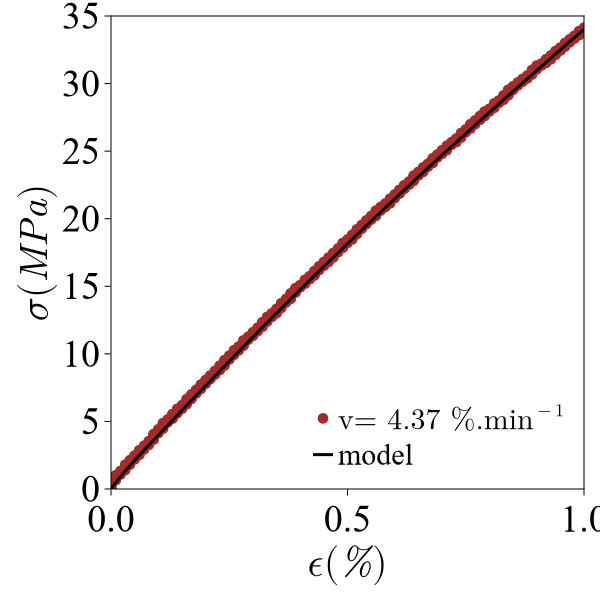

In [248]:
fig = Figure(resolution = (600, 600));

font=40
ax = Axis(fig[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (0,1,0,35)
    )

    Makie.scatter!(ax,ϵ_exp[2]*100,σ_exp[2]/1e6;
     label = L"v= 4.37 %.$\mathrm{min^{-1}}$",
     markersize = 15, 
      color = :brown)

    Makie.lines!(ax,ϵ_exp[2]*100,σ_sim[2]/1e6;
     linewidth = 3, 
     label = "model",
     color = :black)
     axislegend(ax, labelsize=font-10, framevisible=false,position = :rb)

     fig

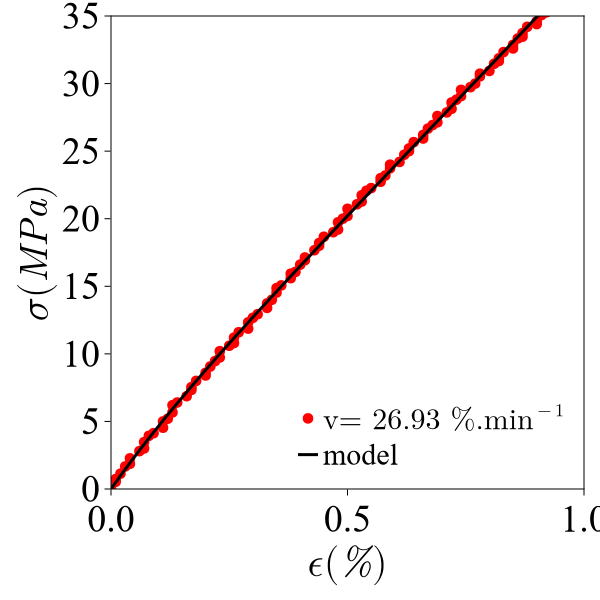

In [242]:
fig = Figure(resolution = (600, 600));

font=40
ax = Axis(fig[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false,
    limits = (0,1,0,35)
    )

    Makie.scatter!(ax,ϵ_exp[4]*100,σ_exp[4]/1e6;
     label = L"v= 26.93 %.$\mathrm{min^{-1}}$",
     markersize = 15, 
      color = :red)

    Makie.lines!(ax,ϵ_exp[4]*100,σ_sim[4]/1e6;
     linewidth = 3, 
     label = "model",
     color = :black)
     axislegend(ax, labelsize=font-10, framevisible=false,position = :rb)

     fig


## Temperature influence

In [166]:

## Fig2 Temperatur Einfluss

σ_exp=[]
ϵ_exp=[]
dϵdt=[]
## Room 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-"
name="251103-"
df_Group=[]

df_Group_Total=[]

for i in [1]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=df[!,:dL_ORG]/100
        df_filtered=filter_range(df,"dL_ORG",0,2.1)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.2703/60)

## 50 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-"
name="251103-"
df_Group=[]
df_Group_Total=[]

for i in [7]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=df[!,:dL_ORG]/100
        df_filtered=filter_range(df,"dL_ORG",0,2.1)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.2545/60)


## 100 27 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-"
name="251103-"
df_Group=[]
df_Group_Total=[]

for i in [10]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:dL_ORG]=df[!,:dL_ORG].-0.6
        df[!,:Strain]=df[!,:dL_ORG]/100
        df_filtered=filter_range(df,"dL_ORG",0,2.1)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.2428/60)


## Fig2


    Makie.scatter!(ax1_2 ,ϵ_exp[1]*100,σ_exp[1]/1e6;
     markersize=14, 
     label = "T22°C v=$(round(dϵdt[1]*60*100, digits=3)) [%/min]",
     color = :black)
    
    Makie.scatter!(ax1_2,ϵ_exp[2]*100,σ_exp[2]/1e6;
      label = "T50°C v=$(round(dϵdt[2]*60*100, digits=3)) [%/min]",
      markersize=14,
      color = :orange)
    
    Makie.scatter!(ax1_2,ϵ_exp[3]*100,σ_exp[3]/1e6;
    label = "T100°C v=$(round(dϵdt[3]*60*100, digits=3)) [%/min]",
    markersize=14, 
    color = :red)
    axislegend(ax1_2, labelsize=font-10, framevisible=false,position = :rb)

    fig2


## Fig3 Strain Rate Einfluss
fig3 = Figure(resolution = (1000, 600));
ax1_3 = Axis(fig3[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

σ_exp=[]
ϵ_exp=[]
dϵdt=[]


##### Strain Rate 0.7638 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK03/251006-0"
name="251006-"
df_Group=[]
df_Group_Total=[]

for i in [2]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=df[!,:dL_ORG]/100
        df_filtered=filter_range(df,"dL_ORG",0.01,2.5)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

df_Group
push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.007638/60)


    ##### Strain Rate 1.43 %/min

    BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK03/251006-0"
    name="251006-"
    df_Group=[]
    df_Group_Total=[]

    for i in [1]
            file_path = "$(BaseName)$(i).csv"
            df=import_TIRA(file_path)
            df[!,:Name]=fill("$(name)$(i)", nrow(df))
            df[!,:Stress]=df[!,:Kraft]*1e-6/As
            df[!,:Strain]=df[!,:dL_ORG]/100
            df_filtered=filter_range(df,"dL_ORG",0.01,2.5)
            push!(df_Group,df_filtered)
            push!(df_Group_Total,df_filtered)
    end

    df_Group
    push!(σ_exp,df_Group[1][!,:Stress]*1e6)
    push!(ϵ_exp,df_Group[1][!,:Strain])
    push!(dϵdt,0.0143/60)



##### Strain Rate 4.44 %/min

BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK03/251006-0"
name="251006-"
df_Group=[]
df_Group_Total=[]

for i in [6]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=df[!,:dL_ORG]/100
        df_filtered=filter_range(df,"dL_ORG",0.01,2.5)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end

df_Group
push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.0444/60)


### Strain rate 27%
BaseName="D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-"
name="251103-"
df_Group=[]
df_Group_Total=[]

for i in [1]
        file_path = "$(BaseName)$(i).csv"
        df=import_TIRA(file_path)
        df[!,:Name]=fill("$(name)$(i)", nrow(df))
        df[!,:Stress]=df[!,:Kraft]*1e-6/As
        df[!,:Strain]=df[!,:dL_ORG]/100
        df_filtered=filter_range(df,"dL_ORG",0.01,2.5)
        push!(df_Group,df_filtered)
        push!(df_Group_Total,df_filtered)
end


push!(σ_exp,df_Group[1][!,:Stress]*1e6)
push!(ϵ_exp,df_Group[1][!,:Strain])
push!(dϵdt,0.2703/60)


for i in 1:length(σ_exp)
    Makie.scatter!(ax1_3 ,ϵ_exp[i]*100,σ_exp[i]/1e6;
    markersize=14, 
    label = "v=$(round(dϵdt[i]*60*100, digits=3)) %/min")
end

 axislegend(ax1_3, labelsize=font-10, framevisible=false,position = :rb)

fig3

ArgumentError: ArgumentError: "D:/01 Projekt/03 Programm/Rini aktuell/Rini/development/zugversuch/AP5ZK04/251103-1.csv" is not a valid file or doesn't exist